<center><H1>Molecular Similarity</H1></center>

## Objectives

<div class="alert alert-block alert-info">
<Strong>Objectives</strong>

- Evaluate structural similarity between molecules using different molecular fingerpints and similarity metrics.
- Evaluate cutoff values for molecular similarity based on distribution of similarity scores for a given fingerprint

Many useful documents/papers describe various aspects of molecular similarity, including molecular fingerprints and similarity measures.  Please read these if you need more details.

- Getting Started with the RDKit in Python<br>
(https://www.rdkit.org/docs/GettingStartedInPython.html#fingerprinting-and-molecular-similarity)

- Fingerprint Generation, GraphSim Toolkit 2.4.2<br>
(https://docs.eyesopen.com/toolkits/python/graphsimtk/fingerprint.html)

- Chemical Fingerprints<br>
(https://docs.chemaxon.com/display/docs/Chemical+Fingerprints)

- Extended-Connectivity Fingerprints<br>
(https://doi.org/10.1021/ci100050t)

- Why is Tanimoto index an appropriate choice for fingerprint-based similarity calculations?<br>
(https://jcheminf.biomedcentral.com/articles/10.1186/s13321-015-0069-3)



## 1. Computation of similarity scores

The "similar structure, similar function" is a powerful guiding force in medicinal chemistry. Structure-activity relationship studies allow chemists to We will start out comparing morphine to codeine and amlodipine. Morphine and codeine act at &mu; opioid receptors to cause analgesia. Amlodipine is a calcium channel blocker that reduces blood pressure. If the similar structure, similar funciton principle applies to these molecules, morphine and codeine should be structurally similar and different from amlodipine.

In [ ]:
import requests
import time

In [ ]:
# we will get SMILES from pubchem using the pubchem compound ID number
cids = [    5288826,  # morphine
            5284371,  # codeine
            2162]     # amlodipine
names=  ['morphine','codeine','amlodipine'] #for easy display of names with structures later

Let's get the SMILES strings from PubChem, generate Mol objects from them, and draw their chemical structures.

In [ ]:
# this code requests all smiles in one PUG REST API request
prolog = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

str_cid = ",".join([ str(x) for x in cids])

url = prolog + "/compound/cid/" + str_cid + "/property/isomericsmiles/txt"
res = requests.get(url)  # the request will return all three smiles in one line
smiles = res.text.split() # split the data into a new list corresponding to morphine, codeine and fentanyl 
print(smiles)

In [ ]:
#display the structures with names in legends
from rdkit import Chem
from rdkit.Chem import Draw

mols = [ Chem.MolFromSmiles(x) for x in smiles ]
Chem.Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200,200), legends=[str(x) for x in names] )

<div class="alert alert-block alert-warning">
<strong>Check your understanding</strong> Write your answers in the following raw cell.

1) On quick inspection how are morphine and codeine structurally different?
2) On quick inspection how different are morphine and amlodipine structurally?
3) Would you expect morphine and amlodipine to bind to &mu; opioid receptors?
4) Would you expect morphine to be a calcium channel blocker?

Now generate MACCS keys for each compound to generate structural keys for comparison.

In [ ]:
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys

fps = [ MACCSkeys.GenMACCSKeys(x) for x in mols ]

Now let's compute the pair-wise similarity scores among them. The default calculation is Tanimoto simililarity. To make higher scores easier to find, they are indicated with the "\*" character(s). The more "\*" you see, the higher the similarity score.

In [ ]:
for i in range(0, len(fps)) :
    for j in range(i+1, len(fps)) :
        
        score = DataStructs.FingerprintSimilarity(fps[i], fps[j])
        print(names[i], "vs.", names[j], ":", round(score,3), end='')
        
        if ( score >= 0.85 ):
            print(" ****")
        elif ( score >= 0.75 ):
            print(" ***")
        elif ( score >= 0.65 ):
            print(" **")
        elif ( score >= 0.55 ):
            print(" *")
        else:
            print(" ")

<div class="alert alert-block alert-warning">
<strong>Check your understanding</strong>

In the code cell below, using similarity scoring determine if you would expect felodipinum (CID = 3333) to be an opioid analgesic or a calcium channel blocker.


In [ ]:
# write your code to compare similarity here


As seen in the above section, two molecules can have very similar structures and have the same biological effect. 


Let's explore a series of class of prescription drugs called *statins* that are used to lower cholesterol. They all work by inhibiting HMG-CoA reductase which is a critical enzyme in the production of cholesterol. Many of these drugs were developed be structurally similar to existing drugs but having fewer side effects or reduce drug-drug interactions. Mevastatin (CID 64715) was the first drug to be developed by never marketed. Pravastatin does not inhibit CYP-450 enzymes. 

In [ ]:
import requests
import time

In [ ]:
statin_cids = [    54454,  # Simvastatin (Zocor)
                   54687,  # Pravastatin (Pravachol)
                   60823,  # Atorvastatin (Lipitor)
                  446155,  # Fluvastatin (Lescol)   
                  446157,  # Rosuvastatin (Crestor)
                 5282452,  # Pitavastatin (Livalo)
                97938126 ] # Lovastatin (Altoprev)

Let's get the SMILES strings from PubChem, generate Mol objects from them, and draw their chemical structures.

In [ ]:
prolog = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

str_statin_cid = ",".join([ str(x) for x in statin_cids])

url = prolog + "/compound/cid/" + str_statin_cid + "/property/isomericsmiles/txt"
res = requests.get(url)
smiles = res.text.split()

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

statins = [ Chem.MolFromSmiles(x) for x in smiles ]
Chem.Draw.MolsToGridImage(statins, molsPerRow=4, subImgSize=(200,200), legends=[str(x) for x in statin_cids] )

Now generate MACCS keys for each compound.

In [ ]:
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys

fps = [ MACCSkeys.GenMACCSKeys(x) for x in statins ]


Now let's compute the pair-wise similarity scores among them. To make higher scores easier to find, they are indicated with the "\*" character(s).

In [ ]:
for i in range(0, len(fps)) :
    for j in range(i+1, len(fps)) :
        
        score = DataStructs.FingerprintSimilarity(fps[i], fps[j])
        print(statin_cids[i], "vs.", statin_cids[j], ":", round(score,3), end='')
        
        if ( score >= 0.85 ):
            print(" ****")
        elif ( score >= 0.75 ):
            print(" ***")
        elif ( score >= 0.65 ):
            print(" **")
        elif ( score >= 0.55 ):
            print(" *")
        else:
            print(" ")


<div class="alert alert-block alert-warning">
<strong>Check your understanding</strong> Write your answer in the following raw cell.

1) Identify the two statins above that had the highest similarity score. What structural features are similar?
2) Look at the structure of 446157, what key feature sets it apart from all other statins? What molecule is it most structurally similar to?


In [ ]:
answer:

1)

2) 



<div class="alert alert-block alert-info">
<strong>Some Medicnal Chemistry history</strong>

CID 97938126 -Lovastatin (Altoprev) was developed first by Merck, Sharp & Dohme in 1976 and was metabolized by 2 CYP enzymes (CYP3A and CYP2C8). CID 54454 -Simvastatin (Zocor) was developed 10 years later at the same company and is metabolized by only one CYP enzyme (CYP3A4). <a href ="https://pmc.ncbi.nlm.nih.gov/articles/PMC7576625/" >They are *me-too* drugs defined as "a pharmacologically active compound that is structurally related to a first‐in‐class compound, regarded as belonging to the same therapeutic class as the original compound, and used for the same therapeutic purposes, but which may differ in some respects, such as specificity of pharmacological action, adverse reactions profile, or drug–drug interactions." </a>



By default, the similarity score is generated using the **Tanimoto** equation:

$\frac{|A \cap B|}{|A \cup B|}$ or  $\frac{|A \cap B|}{|A| + |B| -|A\cap B|}$ or $\frac{overlap}{|Unique A + Unique B - Overlap|}$

RDKit also supports other similarity metrics, including Dice, Cosine, Sokal, Russel, Kulczynski, McConnaughey, and Tversky.  The definition of these metrics is available at the following LibreTexts page (https://chem.libretexts.org/Courses/Intercollegiate_Courses/Cheminformatics/06%3A_Molecular_Similarity).

You found that 446157 was quite different from the others with a highest Tanimoto similarity of 0.535. 
The following code cell shows comparison of CIDS 60823 vs. 446157 (Atorvastatin vs Rosuvstatin) using different similary indices.

In [ ]:
print("Tanimoto    :", round(DataStructs.TanimotoSimilarity(fps[2], fps[4]), 4))
print("Dice        :", round(DataStructs.DiceSimilarity(fps[2], fps[4]), 4))
print("Cosine      :", round(DataStructs.CosineSimilarity(fps[2], fps[4]), 4))
print("Sokal       :", round(DataStructs.SokalSimilarity(fps[2], fps[4]), 4))
print("McConnaughey:", round(DataStructs.McConnaugheySimilarity(fps[2], fps[4]), 4))

By using different similarity scores, we can see that these molecules may be more or less similar depending on definition.

The **Tversky score** is an asymmetric similarity measure, and its computation requires the weightings (&alpha; and &beta;) of the two molecules being compared. <br> This allows for emphasizing features that are present in one set or prototype, that are not in the other. 
Setting ***&alpha; = &beta; =1*** produces the **Tanimoto Index**, while setting ***&alpha; = &beta; = 0.5*** is the same as the **Dice index**.


When &alpha; > &beta; we are screening to indicate that molecules must have certain features. If second molecule has extra features, that is OK, but must have key features of the first molecule.  “You must include my core structure, but you can decorate it.”

When &alpha; < &beta; we are screening to indicate that molecules must have certain features. If second molecules has extra features, that is not OK, we want the second molecule to be as close to the first molecule as possible. “Don’t stray too far from the original molecule; I want tight structural similarity.”

In the code example below we are comparing similarity using the Tversky index of CIDS 54454 vs. 54687 (Simvastatin vs Pravastatin). 

In [ ]:
print("Tanimoto CIDS 54454 vs. 54687   :", round(DataStructs.TanimotoSimilarity(fps[0], fps[1]), 4))
print("Dice CIDS 54454 vs. 54687       :", round(DataStructs.DiceSimilarity(fps[0], fps[1]), 4))
print()

for i in range(0,11) :
    
    alpha = round( i * 0.1, 1 )
    beta = round( 1 - alpha, 1 )
    print("(alpha, beta) = (", alpha, ",", beta, ") : ", end='')
    print(round(DataStructs.TverskySimilarity( fps[0], fps[1], alpha, beta ), 4))

print()
print("When alpha and beta = 1")
alpha= 1
beta = 1
print("(alpha, beta) = (", alpha, ",", beta, ") : ", end='')
print(round(DataStructs.TverskySimilarity( fps[0], fps[1], alpha, beta ), 4), " which equals Tanimoto similarity calculation above")
print()
print("When alpha and beta = 0.5")
alpha= 0.5
beta = 0.5
print("(alpha, beta) = (", alpha, ",", beta, ") : ", end='')
print(round(DataStructs.TverskySimilarity( fps[0], fps[1], alpha, beta ), 4), " which equals Dice similarity calculation above")
statins = [ Chem.MolFromSmiles(x) for x in smiles ]
compare = []
compare.append(statins[0])
compare.append(statins[1])

from rdkit.Chem import AllChem
template = Chem.MolFromSmiles('C1=C2C(CCC1)CCC=C2')
AllChem.Compute2DCoords(template)

for m in compare:
   AllChem.GenerateDepictionMatching2DStructure(m,template)

Chem.Draw.MolsToGridImage(compare, molsPerRow=2, subImgSize=(200,200), legends=[str(statin_cids[0])+"(Simvastatin)",str(statin_cids[1])+("(Pravastatin)")] )

<div class="alert alert-block alert-warning">
<strong>Check your understanding</strong> Write your answer in the following raw cell.

1) Which values of  &alpha;  and &beta; indicate that we are penalizing features missing from the first molecule (query molecule)and extra features in the second molecule (target molecule) do not reduce similarity at all? 

2) Why is the similarity lowest for this series when &alpha; = 0 and &beta; = 1?

#### Maximum Common Edge Substructure (MCES)  

Recall in <a href = "https://github.com/ebucholtz/CHEM3351_Summer2026/blob/main/modules/03_Chemical_Representations/03_3_Substructure_Searching_with_SMARTS_Activity.ipynb" >  Activity 03_3 we explored substructure searching with SMARTS </a> we were able to identify and highlight substructures in molecules. For example, we could define a SMARTS pattern and search a molecule for a matching structural feature.

In the example below, acetylsalicylic acid (aspirin) is searched for an **aromatic ring attached to oxygen**:


In [ ]:
ASA = Chem.MolFromSmiles(' CC(=O)OC1=CC=CC=C1C(=O)O')  # Example SMILES for acetylsalicylic acid
query_smarts = "c1ccccc1[#8]"  # SMARTS for an aromatic ring bonded to oxygen
new_query = Chem.MolFromSmarts(query_smarts)  # Example SMARTS for aryl-O substructure
ASA_matches = ASA.GetSubstructMatch(new_query)  # Get indices of matching
print(f"Acetylsalicylic acid matches for phenol group: {ASA_matches}")
ASA

We can extend this same idea to compare two molecules at once and identify the largest atom-and-bond framework they share in common. One way to do this in RDKit is with **RascalMCES** (Rapid Similarity CALculation), which finds the **maximum common edge substructure (MCES)** between two molecules.

RascalMCES compares two molecules by treating each molecule as a graph, where atoms are vertices and bonds are edges. It then searches for the largest set of bonds and atoms that the two molecules have in common (*Note: it can also return a multi-fragment common substructure if more than one part is in common.*). This shared atom-and-bond pattern is called the maximum common edge substructure, or MCES.

The result tells us which part of molecule 1 corresponds to a similar part of molecule 2. In our code, RascalMCES finds the common substructure, and then RDKit uses the matched atom indices to highlight that shared region in both molecules.

Unlike fingerprint similarity, which compares molecules using simplified bit strings, RascalMCES compares the molecular structures more directly. It asks: **What is the largest structural framework these two molecules share?**

To do so, RascalMCES uses a similarity measure called the **Johnson similarity**:

\begin{equation}
similarity =\frac{(E(MCES) + V(MCES))^2}{(E(Mol1) + V(Mol1)) * (E(Mol2) + V(Mol2))}
\end{equation}

where
- E= number of edges(bonds)
- V= number of vertices(atoms)

Thus, E(MCES) and V(MCES) describe the common substructure, while E(Mol1), V(Mol1), E(Mol2), and V(Mol2) describe the two full molecules.

The Johnson similarity values range from 0.0 to 1.0, where 1.0 indicates identical structural graphs and 0.0 indicates no common bonds.

The RascalMCES similarity score asks: 

*How much of the atom-and-bond graph of each molecule is explained by the largest common substructure?*

This is different from Tanimoto similarity, which compares fingerprints rather than the molecular graph directly. Molecular fingerprints are simplified bit-vector representations of molecular features. Because Tanimoto similarity and RascalMCES similarity measure similarity in different ways, their numerical values do not necessarily match.

MCES SMARTS: CCC(-C)-C(=O)-OC1CCC=C2C1C(-C(-C=C2)-C)-CCCCC(-CC(=O)-O)-O
MCES Similarity CIDS 54454 vs. 54687: 0.8590692755156002
Number of fragments: 1
Tanimoto Score CIDS 54454 vs. 54687   : 0.8125


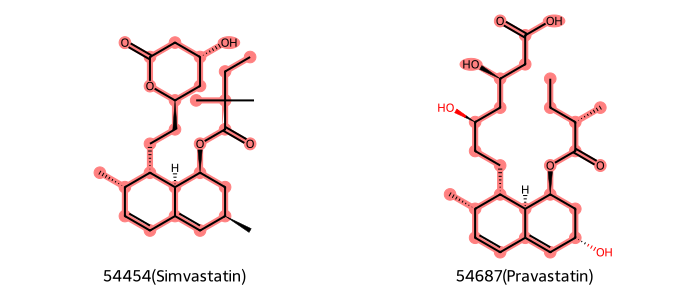

In [94]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdRascalMCES # allows us to calculate 
from rdkit import DataStructs # allows us to calculate TanimotoSimilarity

mol1 = compare[0]
mol2 = compare[1]

results = rdRascalMCES.FindMCES(mol1, mol2)
if len(results) == 0:
    print("No MCES found.")
else:
    mces = results[0]

    print("MCES SMARTS:", mces.smartsString)
    print("MCES Similarity CIDS 54454 vs. 54687:", mces.similarity)
    print("Number of fragments:", mces.numFragments)

    print("Tanimoto Score CIDS 54454 vs. 54687   :", round(DataStructs.TanimotoSimilarity(fps[0], fps[1]), 4))

    atom_matches = mces.atomMatches()

    mol1_match = [x[0] for x in atom_matches]
    mol2_match = [x[1] for x in atom_matches]

    img = Draw.MolsToGridImage(
        [mol1, mol2],
        molsPerRow=2,
        subImgSize=(350, 300),
        legends=["54454(Simvastatin)", "54687(Pravastatin)"],
        highlightAtomLists=[mol1_match, mol2_match]
    )

img

<div class="alert alert-block alert-warning">
<strong>Check your understanding</strong> Write your answer in the following raw cell.

1) Why are the values for Tanimoto score and MCES Similarity different?

2) Alter the code in the cell following the raw cell to compare CID 54454 to itself. Write the value of the output below. Are you surprized by this result? Why or why not?

In [ ]:
# code cell for Check your understanding Question 2.

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdRascalMCES # allows us to calculate 
from rdkit import DataStructs # allows us to calculate TanimotoSimilarity

mol1 = compare[0]
mol2 = compare[1]

results = rdRascalMCES.FindMCES(mol1, mol2)
if len(results) == 0:
    print("No MCES found.")
else:
    mces = results[0]

    print("MCES SMARTS:", mces.smartsString)
    print("MCES Similarity CIDS 54454 vs. 54687:", mces.similarity)
    print("Number of fragments:", mces.numFragments)

    print("Tanimoto Score CIDS 54454 vs. 54687   :", round(DataStructs.TanimotoSimilarity(fps[0], fps[1]), 4))

    atom_matches = mces.atomMatches()

    mol1_match = [x[0] for x in atom_matches]
    mol2_match = [x[1] for x in atom_matches]

    img = Draw.MolsToGridImage(
        [mol1, mol2],
        molsPerRow=2,
        subImgSize=(350, 300),
        legends=["54454(Simvastatin)", "54687(Pravastatin)"],
        highlightAtomLists=[mol1_match, mol2_match]
    )

img

## 2. Interpretation of similarity scores

Using molecular fingeprints. we can compute the similarity scores between molecules.  However, how should these scores be interpreted?  For example, the Tanimoto score between CID 60823 and CID 446155 is computed to be 0.662, but does it mean that the two compounds are similar?  How similar is similar?  The following analysis will help answer these questions.

In [ ]:
#run this code cell to refresh redraw these CIDs and have a mental picture of how similar they are
subset = statins[2:4]
subset_legends = [str(statin_cids[i]) for i in range(2, 4)]

Draw.MolsToGridImage(subset, molsPerRow=2, subImgSize=(200, 200), legends=subset_legends)

**Step 1.** Randomly select 1,000 compounds from PubChem and download their SMILES strings.

In [ ]:
import random
#random.seed(0) #choosing a random seed let's us have reproducable sequences of random numbers. When the seed is set
               #the random numbers generated will be the the same every time the code is run.

cid_max = 121413818  # The maximum CID in PubChem as of May 2025

cids = []

for x in range(1000):
    cids.append(random.randint(1, cid_max + 1))  #picks a random number between 1 and max number of CIDS

chunk_size = 100

if len(cids) % chunk_size == 0 :                    # set up chunks to request SMILES in batches of 100
    num_chunks = int( len(cids) / chunk_size )
else :
    num_chunks = int( len(cids) / chunk_size ) + 1

smiles = []
    
for i in range(num_chunks):

    if (i == 0):
        print("Processing chunk ", end='')
    
    print(i, end=' ')
    
    idx1 = chunk_size * i
    idx2 = chunk_size * (i + 1)
    str_cids = ",".join([ str(x) for x in cids[idx1:idx2]])

    url = prolog + "/compound/cid/" + str_cids + "/property/isomericsmiles/txt"
    res = requests.get(url)

    if ( res.status_code == 200) :
        smiles.extend( res.text.split() )
    else :
        print("Chunk", i, "Failed to get SMILES.")
        
    time.sleep(0.2)

print("Done!")
print("# Number of SMILES : ", len(smiles))

**Step 2.** Generate the MACCSKeys for each compound.

In [ ]:
from rdkit import Chem

mols = [ Chem.MolFromSmiles(x) for x in smiles if x != None ]
fps  = [ MACCSkeys.GenMACCSKeys(x) for x in mols if x != None ]
print("# Number of compounds:", len(mols))
print("# Number of fingerprints:", len(fps))

In [ ]:
# Run this cell if the number of compounds != the number of fingerprints.
#if ( len(cids) != len(fps) ):
#    print("SMILES at index", mols.index(None), ":", smiles[ mols.index(None) ])

**Step 3.** Compute the Tanimoto scores between compounds.

In [ ]:
print("# The number of compound pairs:", (len(fps) * (len(fps) - 1))/2 )

In [ ]:
scores = []

for i in range(0, len(fps)) :

    if (i == 0) :
        print("Processing compound ", end='')
    
    if (i % 100 == 0) :
        print(i, end=' ')
    
    for j in range(i+1, len(fps)) :    #avoids self- and redundant comparisons
        scores.append(DataStructs.FingerprintSimilarity(fps[i], fps[j]))

print("Done!")
print("# Number of scores : ", len(scores))

**Step 4.** Generate a histogram that shows the distribution of the pair-wise scores.

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
mybins = [ x * 0.01 for x in range(101)]

fig = plt.figure(figsize=(8,4), dpi=300)

plt.subplot(1, 2, 1)
plt.title("Distribution")
plt.hist(scores, bins=mybins)
plt.xticks([x * 0.1 for x in range(11)])
plt.grid(axis='x')

plt.subplot(1, 2, 2)
plt.title("Cumulative Distribution")
plt.hist(scores, bins=mybins, density=True, cumulative=1)
plt.plot([0,1],[0.95,0.95], linestyle='-', color='orange');
plt.xticks([x * 0.1 for x in range(11)])
plt.grid(axis='x')
plt.annotate("95th percentile threshold", 
             xy=(0.56, 0.95),            # (x, y) location of the point to annotate
             xytext=(0.0, 0.97),        # position of the label text
             arrowprops=dict(arrowstyle="->", color='red'),
             fontsize=8)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<strong>Check your understanding</strong> Write your answer in the following raw cell.

1) What shape is the histogram distribution? (bell shaped, uniform, bimodal, multimodal, skewed, random)
2) What does the shape tell you about the distribution?
3) What is the approximate median of all Tanimoto scores?
4) What is the approximate score for the top 5% of Tanimoto scores in this distribution?

In [ ]:
Answers:
1)

2)

3)

4)


For each Tanimoto similarity threshold, we'll count how many scores are $\geq$ the threshold and calculate the percentage of scores that meet or exceed it. 

In [ ]:
for i in range(21) :

    thresh = i / 20 
    num_similar_pairs = len([x for x in scores if x >= thresh]) 
    prob = num_similar_pairs / len(scores) * 100
    print("%.3f %8d (%8.4f %%)" % (thresh, num_similar_pairs, round(prob,4)))

In [ ]:
import statistics
print("Average (mean):%.3f" %(statistics.mean(scores)))
print("Median        :%.3f" %(statistics.median(scores)))

From the distribution of the similarity scores among 1,000 compounds, we observe the following:<br>
- If you randomly select two compounds from PubChem, the similarity score between them (computed using the Tanimoto equation and MACCS keys) is ~0.35 on average.
- About %5 of randomly selected compound pairs have a similarity score greater than 0.55.
- About %1 of randomly selected compound pairs have a similarity score greater than 0.65.

If two compounds have a Tanimoto score of 0.35, it is close to the average Tanimoto score between randomly selected compounds and there is a 50% chance that you will get a score of 0.35 or greater just by selecting two compounds from PubChem.  Therefore, it is reasonable to consider the two compounds are not similar.<br>

The Tanimoto index may have a value ranging from 0 (for no similarity) to 1 (for identical molecules) and the midpoint of this value range is 0.5.  Because of this, a Tanimoto score of **0.55** may not sound great enough to consider two compounds to be similar.  However, according to the score distribution curve generated here, only **~5%** of randomly selected compound pairs will have a score greater than this.<br>

In the previous section, we computed the similarity scores between some cholesterol-lowering drugs, and CID 60823 and CID 446155 had a Tanimoto score of **0.662**.  Based on the score distribution curve generated in the second section, we can say that the probablilty of two randomly selected compounds from PubChem having a Tanimoto score greater than 0.662 is **less than 1%**.

The following code cell demonstrates how to find an appropriate similarity score threshold above which a given percentage of the compound pairs will be considered to be similar to each other.

In [ ]:
scores.sort()    # Sort the scores in an increasing order.

In [ ]:
# to find a threshold for top 3% compound pairs (i.e., 97% percentile)
print("# total compound pairs:   ", len(scores))
print("# 97% of compound pairs:  ", len(scores) * 0.97)
print("# score at 97% percentile:", scores[ round(len(scores) * 0.97) ] )
